In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, cohen_kappa_score, fbeta_score

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, CSVLogger

import keras_cv   # 🔥 REQUIRED for ViT

print(f"TensorFlow Version: {tf.__version__}")

# GPU check
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"GPU detected: {len(gpus)}")
    from tensorflow.keras import mixed_precision
    mixed_precision.set_global_policy('mixed_float16')
    print("Mixed Precision Enabled")
else:
    print("No GPU detected")


TensorFlow Version: 2.16.1
No GPU detected


In [ ]:
!pip install keras-cv

  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Using cached importlib_resources-6.5.2-py3-none-any.whl.metadata (3.9 kB)
   ---------------------------------------- 0.0/650.7 kB ? eta -:--:--
   ----- ---------------------------------- 92.2/650.7 kB 1.7 MB/s eta 0:00:01
   --------------- ------------------------ 245.8/650.7 kB 2.5 MB/s eta 0:00:01
   ------------------------------ --------- 501.8/650.7 kB 3.9 MB/s eta 0:00:01
   ---------------------------------------  645.1/650.7 kB 4.0 MB/s eta 0:00:01
   ---------------------------------------- 650.7/650.7 kB 3.4 MB/s eta 0:00:00
   ---------------------------------------- 0.0/68.3 kB ? eta -:--:--
   ---------------------------------------- 68.3/68.3 kB 3.6 MB/s eta 0:00:00
   ---------------------------------------- 0.0/950.8 kB ? eta -:--:--
   ----------------------------- --------- 716.8/950.8 kB 22.1 MB/s eta 0:00:01
   --------------------------------------  942.1/950.


[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
TRAIN_CSV = 'train.csv'
TRAIN_IMG_DIR = 'train_images'

IMG_SIZE = (384, 384)
BATCH_SIZE = 16
EPOCHS = 5
SEED = 42
NUM_CLASSES = 5

np.random.seed(SEED)
tf.random.set_seed(SEED)


In [ ]:
df = pd.read_csv(TRAIN_CSV)
df['id_code'] = df['id_code'].astype(str) + '.png'
df['diagnosis'] = df['diagnosis'].astype(str)

print(f"Total samples: {len(df)}")


Total samples: 3662


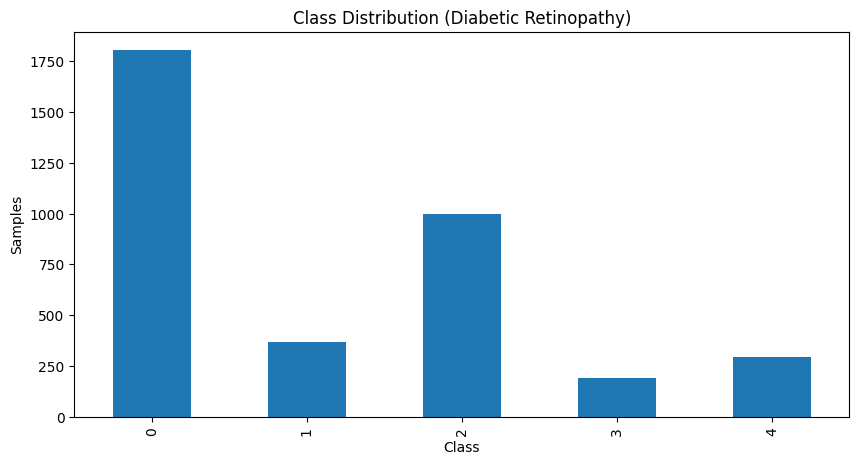

In [ ]:
plt.figure(figsize=(10,5))
df['diagnosis'].value_counts().sort_index().plot(kind='bar')
plt.title("Class Distribution (Diabetic Retinopathy)")
plt.xlabel("Class")
plt.ylabel("Samples")
plt.show()


In [ ]:
train_df, val_df = train_test_split(
    df,
    test_size=0.15,
    stratify=df['diagnosis'],
    random_state=SEED
)

print("Train:", len(train_df))
print("Val:", len(val_df))


Train: 3112
Val: 550


In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    horizontal_flip=True,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_dataframe(
    train_df,
    directory=TRAIN_IMG_DIR,
    x_col='id_code',
    y_col='diagnosis',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    shuffle=True,
    seed=SEED
)

val_gen = val_datagen.flow_from_dataframe(
    val_df,
    directory=TRAIN_IMG_DIR,
    x_col='id_code',
    y_col='diagnosis',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    shuffle=False
)


Found 3112 validated image filenames belonging to 5 classes.
Found 550 validated image filenames belonging to 5 classes.


In [ ]:
classes = np.unique(train_df['diagnosis'])
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=train_df['diagnosis'].values
)

class_weight_dict = dict(zip(classes, class_weights))
print("Class Weights:", class_weight_dict)


Class Weights: {'0': 0.4057366362451108, '1': 1.9821656050955414, '2': 0.7330977620730271, '3': 3.795121951219512, '4': 2.4796812749003982}


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, Model
from vit_keras import vit
def build_vit_model(input_shape=(384, 384, 3), n_classes=NUM_CLASSES):
    """
    Vision Transformer (ViT-B/16) using vit-keras
    """

    vit_model = vit.vit_b16(
        image_size=384,
        activation='softmax',
        pretrained=True,
        include_top=True,
        pretrained_top=False,
        classes=n_classes
    )

    vit_model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=3e-5),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return vit_model
model = build_vit_model()
model.summary()


Model: "vit-b16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 384, 384, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Conv2D)              │ (None, 24, 24, 768)    │       590,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 576, 768)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ class_token (ClassToken)        │ (None, 577, 768)       │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Transformer_posembed_input      │ (None, 577, 768)       │       443,136 │
│ (AddPositionEmbs)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Transformer_encoderblock_0      │ [(None, 577, 768),     │     7,087,872 │
│ (TransformerBlock)              │ (None, 12, None,       │               │
│                                 │ None)]                 │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Transformer_encoderblock_1      │ [(None, 577, 768),     │     7,087,872 │
│ (TransformerBlock)              │ (None, 12, None,       │               │
│                                 │ None)]                 │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Transformer_encoderblock_2      │ [(None, 577, 768),     │     7,087,872 │
│ (TransformerBlock)              │ (None, 12, None,       │               │
│                                 │ None)]                 │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Transformer_encoderblock_3      │ [(None, 577, 768),     │     7,087,872 │
│ (TransformerBlock)              │ (None, 12, None,       │               │
│                                 │ None)]                 │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Transformer_encoderblock_4      │ [(None, 577, 768),     │     7,087,872 │
│ (TransformerBlock)              │ (None, 12, None,       │               │
│                                 │ None)]                 │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Transformer_encoderblock_5      │ [(None, 577, 768),     │     7,087,872 │
│ (TransformerBlock)              │ (None, 12, None,       │               │
│                                 │ None)]                 │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Transformer_encoderblock_6      │ [(None, 577, 768),     │     7,087,872 │
│ (TransformerBlock)              │ (None, 12, None,       │               │
│                                 │ None)]                 │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Transformer_encoderblock_7      │ [(None, 577, 768),     │     7,087,872 │
│ (TransformerBlock)              │ (None, 12, None,       │               │
│                                 │ None)]                 │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Transformer_encoderblock_8      │ [(None, 577, 768),     │     7,087,872 │
│ (TransformerBlock)              │ (None, 12, None,       │               │
│                                 │ None)]                 │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Transformer_encoderblock_9      │ [(None, 577, 768),     │     7,087,872 │
│ (TransformerBlock)              │ (None, 12, None,       │             

 Total params: 86,094,341 (328.42 MB)

 Trainable params: 86,094,341 (328.42 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.callbacks import (
    ModelCheckpoint,
    EarlyStopping,
    ReduceLROnPlateau,
    CSVLogger
)

callbacks_list = [
    # Save best ViT model
    ModelCheckpoint(
        filepath="best_model_vit.h5",
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1
    ),

    # Stop if validation accuracy stops improving
    EarlyStopping(
        monitor="val_accuracy",
        patience=5,
        restore_best_weights=True,
        mode="max",
        verbose=1d
    ),

    # Reduce LR when validation loss plateaus
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-7,
        verbose=1
    ),

    # Log training history (for research paper plots)
    CSVLogger(
        filename="training_log_vit.csv",
        separator=",",
        append=False
    )
]


In [ ]:
history_vit = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    class_weight=class_weight_dict,
    callbacks=callbacks_list,
    verbose=1
)


Epoch 1/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 23s/step - accuracy: 0.7001 - loss: 0.8882
Epoch 1: val_accuracy improved from None to 0.76727, saving model to best_model_vit.h5
195/195 ━━━━━━━━━━━━━━━━━━━━ 4821s 24s/step - accuracy: 0.7407 - loss: 0.7075 - val_accuracy: 0.7673 - val_loss: 0.6241 - learning_rate: 3.0000e-05

Epoch 2/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 14s/step - accuracy: 0.7994 - loss: 0.5337
Epoch 2: val_accuracy improved from 0.76727 to 0.8082, saving model to best_model_vit.h5
195/195 ━━━━━━━━━━━━━━━━━━━━ 2907s 15s/step - accuracy: 0.8001 - loss: 0.5158 - val_accuracy: 0.8082 - val_loss: 0.6308 - learning_rate: 3.0000e-05

Epoch 3/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 14s/step - accuracy: 0.8384 - loss: 0.4383
Epoch 3: val_accuracy improved from 0.8082 to 0.8583, saving model to best_model_vit.h5
195/195 ━━━━━━━━━━━━━━━━━━━━ 2857s 15s/step - accuracy: 0.8323 - loss: 0.4533 - val_accuracy: 0.8583 - val_loss: 0.6109 - learning_rate: 3.0000e-05

Epoch 4/10
195/195 ━━━━━━━━━━━━

In [ ]:
from tensorflow.keras.models import load_model

model = load_model(
    "best_model_vit.h5",
    safe_mode=False
)

print("✅ Best-performing ViT model loaded")


✅ Best-performing ViT model loaded


In [ ]:
loss, acc = model.evaluate(val_gen, verbose=1)

print(f"Validation Accuracy : {acc:.4f}")
print(f"Validation Loss     : {loss:.4f}")



35/35 ━━━━━━━━━━━━━━━━━━━━ 157s 4s/step - accuracy: 0.9250 - loss: 0.2183
Validation Accuracy : 0.9250
Validation Loss     : 0.2183



In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Predictions
y_pred_probs = model.predict(val_gen)
y_pred = np.argmax(y_pred_probs, axis=1)

# True labels
y_true = val_gen.classes

# Class names
class_names = list(val_gen.class_indices.keys())

# Classification Report
print("\n📊 Classification Report (Best ViT Model)\n")
print(classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4
))



35/35 ━━━━━━━━━━━━━━━━━━━━ 156s 4s/step

📊 Classification Report (Best ViT Model)

              precision    recall  f1-score   support

           0     0.9900    0.9852    0.9876       271
           1     0.8654    0.8750    0.8702        56
           2     0.9180    0.9067    0.9123       150
           3     0.8519    0.8966    0.8737        29
           4     0.9024    0.8864    0.8943        44

    accuracy                         0.9250       550
   macro avg     0.9055    0.9100    0.9076       550
weighted avg     0.9260    0.9250    0.9254       550



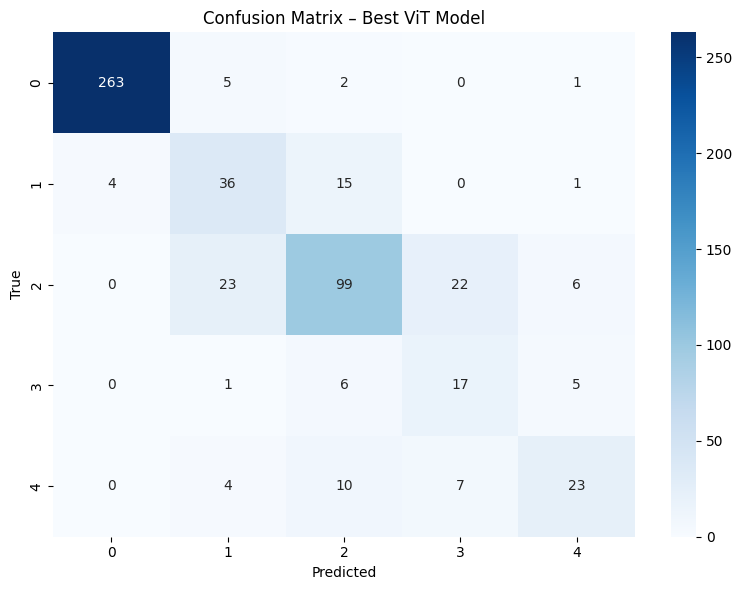

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix – Best ViT Model")
plt.tight_layout()
plt.show()
